## 1.- Implementación de una CNN para clasificación de imágenes

En esta primera sección, el alumno debe de implementar una red neuronal convolucional para clasificación de imágenes con el dataset CIFAR-100, que consiste en imágenes de 100 clases de objetos diferentes, frene a los 10 que usaba su dataset hermano, CIFAR-10.

Antes de empezar con el ejercicio, es importante plantearnos las siguientes preguntas, que son parte de la evaluación de la tarea y que habrá que responder en el documento de la tarea de los temas 3-4:

- 1. ¿Necesitaré una arquitectura igual a la utilizada para CIFAR-10?

R: No exactamente, CIFAR-100 tiene mucho más clase que CIFAR-10, o sea, es más dificil porque la aquitectura tiene que ser más robusta.

- 2. ¿Será un problema más o menos complicado para la red neuronal?

R: Más complicado. És mas dificil para la red aprendera diferenciar las imágenes.

- 3. A la hora de evaluar las métricas, ¿debemos interpretarlas de la misma manera que cuando usamos CIFAR-10?

R: No, deberíamos ser más flexibles. Para el CIFAR-100, una precisión del 35%-40% está bien para empezar, mientras que en CIFAR-10 esperamos valores más altos.

- 4. Si ya tengo una arquitectura válida para el dataset CIFAR-10, ¿qué es lo mínimo que tengo que cambiar de la red para poder entrenar la nueva red con CIFAR-100?

R: Cambiar la capa de salida. CIFAR-10 tiene 10 neuronas en la capa de salida, mientras CIFAR-100 tiene 100 neuronas.

Para complicar más el reto, se limita el número de capas ocultas (incluyendo capas convolucionales y densas) a 6 (la capa de salida no cuenta).

*Nota: el dataset CIFAR-100 es un dataset muy complejo de trabajar, ya que tiene de una gran cantidad de posibles clases (100). No te preocupes si no consigues un accuracy alto; a más clases, más complicado es el problema. Con un prototipo rápido a penas he alcanzado un 36% de accuracy.*




In [6]:
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Cargar el conjunto de datos CIFAR-100
(x_train, y_train), (x_test, y_test) = cifar100.load_data()
n_classes = 100

# Normalizar los datos de píxeles en el rango [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Convertir las etiquetas a vectores one-hot
y_train = to_categorical(y_train, n_classes)
y_test = to_categorical(y_test, n_classes)

# Configurar la aumentación de datos
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    )

datagen.fit(x_train)

# Definir el modelo de la red neuronal convolucional
model = Sequential()

# Primera capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=x_train.shape[1:]))
# Segunda capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# Primera capa de pooling
model.add(MaxPooling2D(pool_size=(2, 2)))
# Agregamos un pequeño dropout para reducir overfitting
model.add(Dropout(0.25))

# Tercera capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
# Cuarta capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
# Segunda capa de pooling
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Aplanamos las salidas para conectarlas a capas densas
model.add(Flatten())

# Capa densa (fully connected)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Capa de salida
model.add(Dense(n_classes, activation='softmax'))

# Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo con aumentación de datos
model.fit(datagen.flow(x_train, y_train, batch_size=64),
          steps_per_epoch=len(x_train) // 64,
          epochs=10,
          validation_data=(x_test, y_test))

# Evaluar el modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 120s 150ms/step - accuracy: 0.0312 - loss: 4.4099 - val_accuracy: 0.1495 - val_loss: 3.6113
Epoch 2/10
  1/781 ━━━━━━━━━━━━━━━━━━━━ 1:27 112ms/step - accuracy: 0.1094 - loss: 3.8602

c:\Users\nunoc\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1094 - loss: 3.8602 - val_accuracy: 0.1513 - val_loss: 3.6134
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 128s 164ms/step - accuracy: 0.1363 - loss: 3.6588 - val_accuracy: 0.2508 - val_loss: 3.1236
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1875 - loss: 3.3403 - val_accuracy: 0.2510 - val_loss: 3.1057
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 132s 170ms/step - accuracy: 0.1981 - loss: 3.3139 - val_accuracy: 0.2850 - val_loss: 2.8799
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1875 - loss: 3.1654 - val_accuracy: 0.2849 - val_loss: 2.8797
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 127s 162ms/step - accuracy: 0.2390 - loss: 3.1002 - val_accuracy: 0.3119 - val_loss: 2.7343
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2656 - loss: 2.9535 - val_accuracy: 0.3120 - val_loss: 2.7414
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 127s 163ms/step - accuracy: 0.2628 - loss: 2.9643 - val_accurac

## 2.- Implementación de una CGAN para generación de imágenes

En este apartado, crearemos una CGAN, similar a la vista en el notebook *conditional-gan.ipynb*, pero para generar imágenes sintéticas a partir del dataset Fashion MNIST. Aquí, nuevamente, cabe preguntarnos varios temas antes de empezar, que también deberán responderse en el fichero de entrega de la tarea 3-4:

- 5. Desde el punto de vista técnico, sin fijarnos aún en la calidad de las imágenes sintetizadas, ¿habría que hacer algún cambio obligatorio con respecto a la red utilizada para sintetizar datos de MNIST? Justifique su respuesta.

R: No, no es obligatorio hacer cambios técnicos. La entrada y la salida tienen el mismo formato, entonces no es necesario cambiar la estructura de la CGAN.

- 6. A priori, ¿piensas que la red generadora y la discriminadora deberán más complejas, igual de complejas, o menos complejas que en el caso de la red utilizada con MNIST para sintetizar datos de calidad suficiente? Justifique su respuesta.

R: Deberán ser un poco más complejas, porque el Fashion MNIST contiene objetos de ropa que son más complejos, como camisetas, zapatos, etc.

*Nota: aquí queremos generar imágenes de muy baja resolución de elementos mucho más complejos que simples dígitos. No os preocupéis si los resultados son lo suficientemente buenos, lo importante es conseguir la*


In [7]:
!pip install -q git+https://github.com/tensorflow/docs

In [8]:
!pip install --upgrade keras

In [9]:
import keras
from keras import layers
from keras import ops
from tensorflow_docs.vis import embed
import tensorflow as tf
import numpy as np
import imageio
import matplotlib.pyplot as plt

In [11]:
# Hiperparámetros
batch_size = 64
num_channels = 1
num_classes = 10
image_size = 28
latent_dim = 128

In [12]:
# Importamos el dataset MNIST, que ya viene separado por X, y y train y test
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
all_clothes = np.concatenate([x_train, x_test])
all_labels = np.concatenate([y_train, y_test])

# Al igual que hemos hecho otras veces, escalamos las imágenes entre 0 y 1
all_clothes = all_clothes.astype("float32") / 255.0
all_clothes = np.reshape(all_clothes, (-1, 28, 28, 1))
all_labels = keras.utils.to_categorical(all_labels, 10)

# Creamos el dataset y separamos en batches
dataset = tf.data.Dataset.from_tensor_slices((all_clothes, all_labels))
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size)

print(f"Shape of training images: {all_clothes.shape}")
print(f"Shape of training labels: {all_labels.shape}")

Shape of training images: (70000, 28, 28, 1)
Shape of training labels: (70000, 10)


¡¡¡OJO!!! Recuerda cuál era el número de dimensiones de entrada en el generador y el discriminador de una GAN condicional.

In [13]:
generator_in_channels = latent_dim + num_classes
discriminator_in_channels = num_channels + num_classes

In [14]:
# Creando el discriminador
discriminator = keras.Sequential(
    [
        layers.Input(shape=(image_size, image_size, discriminator_in_channels)),
        layers.Conv2D(64, kernel_size=3, strides=2, padding="same", activation="relu"),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same", activation="relu"),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="discriminator",
)

# Creando el generador
generator = keras.Sequential(
    [
        layers.Input(shape=(generator_in_channels,)),
        layers.Dense(7 * 7 * 128, activation="relu"),
        layers.Reshape((7, 7, 128)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", activation="relu"),
        layers.Conv2D(num_channels, kernel_size=7, activation="sigmoid", padding="same"),
    ],
    name="generator",
)

In [15]:
class ConditionalGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(1337)
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        # Unpack the data.
        real_images, one_hot_labels = data

        # Add dummy dimensions to the labels so that they can be concatenated with
        # the images. This is for the discriminator.
        image_one_hot_labels = one_hot_labels[:, :, None, None]
        image_one_hot_labels = ops.repeat(
            image_one_hot_labels, repeats=[image_size * image_size]
        )
        image_one_hot_labels = ops.reshape(
            image_one_hot_labels, (-1, image_size, image_size, num_classes)
        )

        # Sample random points in the latent space and concatenate the labels.
        # This is for the generator.
        batch_size = ops.shape(real_images)[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )
        random_vector_labels = ops.concatenate(
            [random_latent_vectors, one_hot_labels], axis=1
        )

        # Decode the noise (guided by labels) to fake images.
        generated_images = self.generator(random_vector_labels)

        # Combine them with real images. Note that we are concatenating the labels
        # with these images here.
        fake_image_and_labels = ops.concatenate(
            [generated_images, image_one_hot_labels], -1
        )
        real_image_and_labels = ops.concatenate([real_images, image_one_hot_labels], -1)
        combined_images = ops.concatenate(
            [fake_image_and_labels, real_image_and_labels], axis=0
        )

        # Assemble labels discriminating real from fake images.
        labels = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )

        # Train the discriminator.
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample random points in the latent space.
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )
        random_vector_labels = ops.concatenate(
            [random_latent_vectors, one_hot_labels], axis=1
        )

        # Assemble labels that say "all real images".
        misleading_labels = ops.zeros((batch_size, 1))

        # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        with tf.GradientTape() as tape:
            fake_images = self.generator(random_vector_labels)
            fake_image_and_labels = ops.concatenate(
                [fake_images, image_one_hot_labels], -1
            )
            predictions = self.discriminator(fake_image_and_labels)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Monitor loss.
        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {
            "g_loss": self.gen_loss_tracker.result(),
            "d_loss": self.disc_loss_tracker.result(),
        }

In [16]:
cond_gan = ConditionalGAN(
    discriminator=discriminator, generator=generator, latent_dim=latent_dim
)

cond_gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=False),
)

cond_gan.fit(dataset, epochs=50)

Epoch 1/50


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 206s 186ms/step - d_loss: 0.1012 - g_loss: 6.0891
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 312s 285ms/step - d_loss: 0.2271 - g_loss: 8.8808
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 204s 187ms/step - d_loss: 0.0022 - g_loss: 7.0305
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 229s 209ms/step - d_loss: 5.3340e-04 - g_loss: 8.3745
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 220s 201ms/step - d_loss: 2.2888e-04 - g_loss: 9.2724
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 215s 197ms/step - d_loss: 1.3748e-04 - g_loss: 10.0100
Epoch 7/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 249s 228ms/step - d_loss: 8.1092e-05 - g_loss: 10.7857
Epoch 8/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 237s 216ms/step - d_loss: 4.9047e-05 - g_loss: 11.4912
Epoch 9/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 256s 234ms/step - d_loss: 3.2080e-05 - g_loss: 12.1954
Epoch 10/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 253s 231ms/step - d_loss: 4.1690e-05 - g_loss: 12.9923
Epoch 11/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 283s 258ms/ste

In [19]:
# Etiquetas a generar. Modificar la lista labels como queramos
labels = [0,1,2,3,2,2,4,5,6,7,8,9]
n_samples = len(labels)

# Extraemos el generador de la CGAN
trained_gen = cond_gan.generator

# Convertimos las etiquetas en labels a categóricas
labels = keras.utils.to_categorical(labels, num_classes)

# Generamos el ruido para las diferentes imágenes a generar.
noise = keras.random.normal(shape=(n_samples, latent_dim))
noise = ops.reshape(noise, (n_samples, latent_dim))

# Concatenamos el ruido y las etiquetas para tener el input entero del generador
noise_and_labels = ops.concatenate([noise, labels], 1)

# Generamos las imágenes con el input
fake_images = trained_gen.predict(noise_and_labels)

# Convertimos a las dimensiones originales (28x28, aunque podríamos modificar los valores) y los valores de los píxeles yendo de 0 a 255 en vez de de 0 a 1
# Aseguramos que los valores están entre 0 y 1
fake_images = np.clip(fake_images, 0.0, 1.0)

# Escalamos los valores a 0–255
fake_images *= 255.0

# Convertimos a enteros válidos para imágenes
converted_images = fake_images.astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


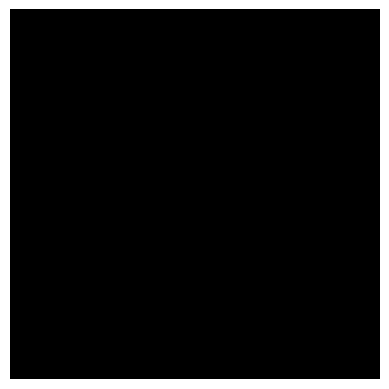

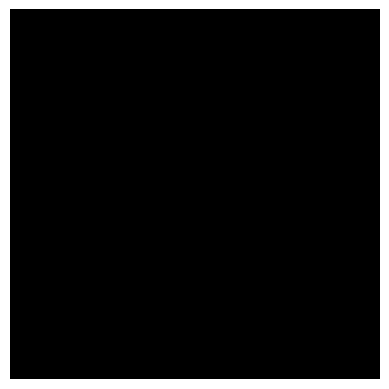

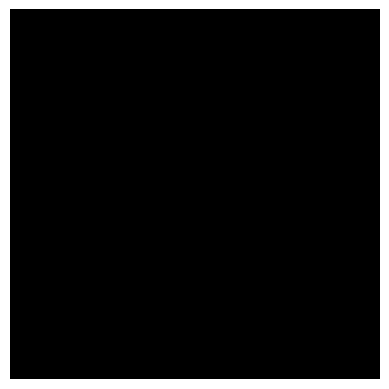

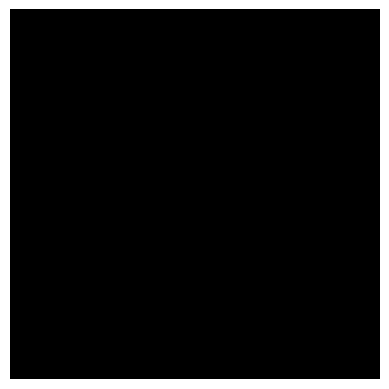

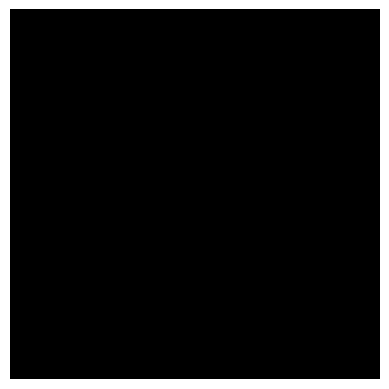

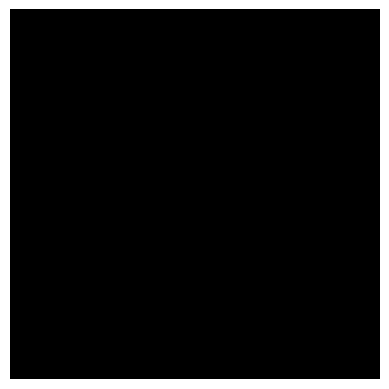

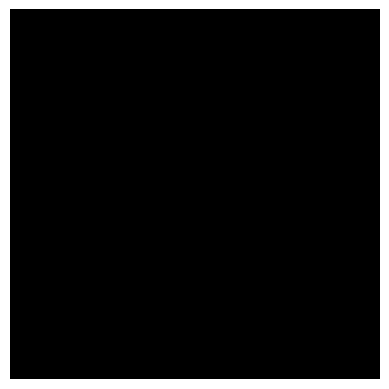

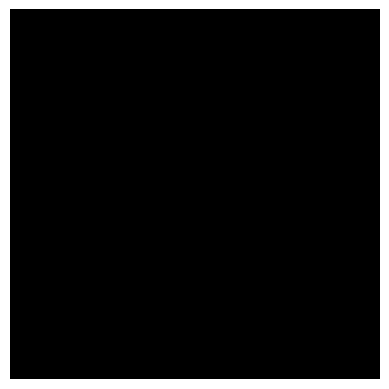

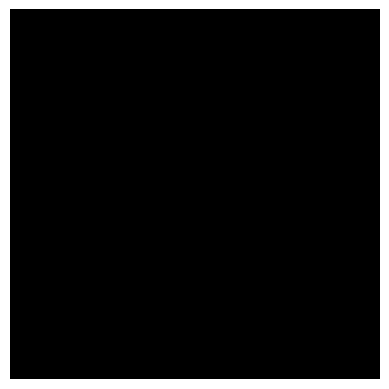

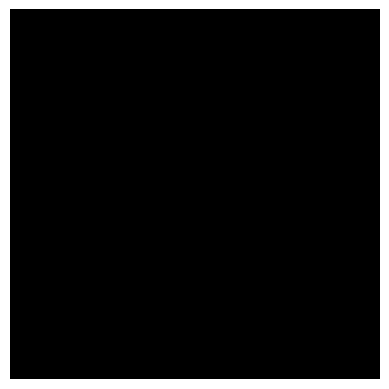

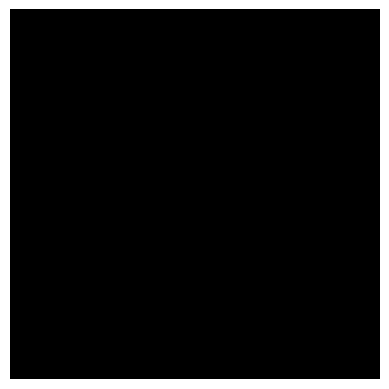

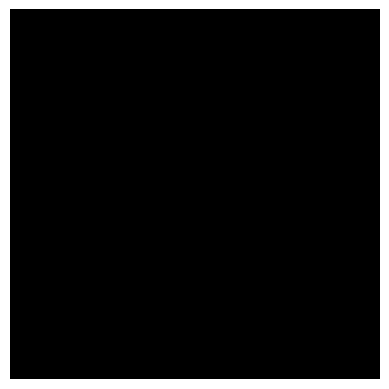

In [20]:
# Por último, mostramos las imágenes
for image in converted_images:
    plt.imshow(image[:,:,0], cmap='gray')
    plt.axis('off')
    plt.show()

In [21]:
fake_images = trained_gen.predict(noise_and_labels)
print("Min:", fake_images.min(), "Max:", fake_images.max())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Min: 0.0 Max: 1.8975248e-27


Parece que el generador ha colapsado, ya que casi todos los píxeles tienen un valor cercano a 0, es decir, negro.